# Experiment No. 04 – Performance Evaluation Metrics for Data Models (Supervised)

**AIM:** Implement and explore performance evaluation metrics for Data Models (Supervised)

## Theory

### Classification Metrics

| Metric | Formula | Evaluation Focus |
|---|---|---|
| **Accuracy** | ACC = (TP + TN) / (TP + TN + FP + FN) | Overall effectiveness of a classifier |
| **Error Rate** | ERR = (FP + FN) / (TP + TN + FP + FN) | Classification error |
| **Precision** | PRC = TP / (TP + FP) | Class agreement of data labels with positive labels given by the classifier |
| **Sensitivity (Recall)** | SNS = TP / (TP + FN) | Effectiveness of a classifier to identify positive labels |
| **Specificity** | SPC = TN / (TN + FP) | How effectively a classifier identifies negative labels |
| **F₁ Score** | F₁ = 2 · (PRC · SNS) / (PRC + SNS) | Combination of precision and sensitivity in a single metric |
| **Geometric Mean** | GM = √(SNS · SPC) | Combination of sensitivity and specificity in a single metric |

- **False Positive Rate (α)** = Type I error = 1 − Specificity = FP / (FP + TN)
- **False Negative Rate (β)** = Type II error = 1 − Sensitivity = FN / (TP + FN)
- **Power** = Sensitivity = 1 − β

### Regression Metrics

| Metric | Formula | Explanation |
|---|---|---|
| **Pearson Correlation (r)** | r = Σ(x−x̄)(y−ȳ) / √[Σ(x−x̄)²·Σ(y−ȳ)²] | Strength of association between predicted and observed values |
| **R² (Coefficient of Determination)** | R² = 1 − SS_res / SS_tot | Fraction of variance explained by the model |
| **Mean Squared Error (MSE)** | MSE = (1/n) Σ(yᵢ − ŷᵢ)² | Most common loss function for regression |
| **Root Mean Squared Error (RMSE)** | RMSE = √MSE | Error rate of a regression model |
| **Mean Absolute Error (MAE)** | MAE = (1/n) Σ|yᵢ − ŷᵢ| | Average absolute difference between predicted and actual |
| **MAPE** | MAPE = (100%/n) Σ|yᵢ − ŷᵢ|/|yᵢ| | Accuracy as a percentage |

### Dataset
**Online Retail Dataset** – Transactional data from a UK-based online retailer.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, roc_auc_score, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load Dataset
df = pd.read_csv('data_online_retail.csv', encoding='unicode_escape')
print(f"Shape: {df.shape}")
df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
# Data Preprocessing
df = df.dropna(subset=['CustomerID'])
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
print(f"Cleaned shape: {df.shape}")
df.info()

Cleaned shape: (397884, 9)
<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397884 non-null  object 
 1   StockCode    397884 non-null  object 
 2   Description  397884 non-null  object 
 3   Quantity     397884 non-null  int64  
 4   InvoiceDate  397884 non-null  object 
 5   UnitPrice    397884 non-null  float64
 6   CustomerID   397884 non-null  float64
 7   Country      397884 non-null  object 
 8   TotalPrice   397884 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 30.4+ MB


---
## Part 1: Classification Metrics

**Task:** Predict whether a transaction is from the **United Kingdom** or not (binary classification).

We will evaluate the classifier using:
Accuracy, Error Rate, Precision, Sensitivity (Recall), Specificity, F₁ Score, Geometric Mean, and ROC-AUC.

In [4]:
# Prepare Classification Data
# Binary target: 1 = United Kingdom, 0 = Other
df['IsUK'] = (df['Country'] == 'United Kingdom').astype(int)

# Features
X_clf = df[['Quantity', 'UnitPrice', 'TotalPrice']]
y_clf = df['IsUK']

# Train-Test Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=42, stratify=y_clf
)

# Scale features
scaler = StandardScaler()
X_train_cs = scaler.fit_transform(X_train_c)
X_test_cs = scaler.transform(X_test_c)

print(f"Training set: {X_train_cs.shape[0]} samples")
print(f"Test set    : {X_test_cs.shape[0]} samples")
print(f"\nClass distribution:\n{y_clf.value_counts()}")

Training set: 278518 samples
Test set    : 119366 samples

Class distribution:
IsUK
1    354321
0     43563
Name: count, dtype: int64


In [5]:
# Train Logistic Regression Classifier
clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(X_train_cs, y_train_c)

# Predictions
y_pred_c = clf.predict(X_test_cs)
y_prob_c = clf.predict_proba(X_test_cs)[:, 1]

print("Classification Report:\n")
print(classification_report(y_test_c, y_pred_c, target_names=['Other', 'UK']))

Classification Report:

              precision    recall  f1-score   support

       Other       0.19      0.00      0.00     13069
          UK       0.89      1.00      0.94    106297

    accuracy                           0.89    119366
   macro avg       0.54      0.50      0.47    119366
weighted avg       0.81      0.89      0.84    119366



Confusion Matrix:
[[    10  13059]
 [    43 106254]]

TP = 106254, TN = 10, FP = 13059, FN = 43


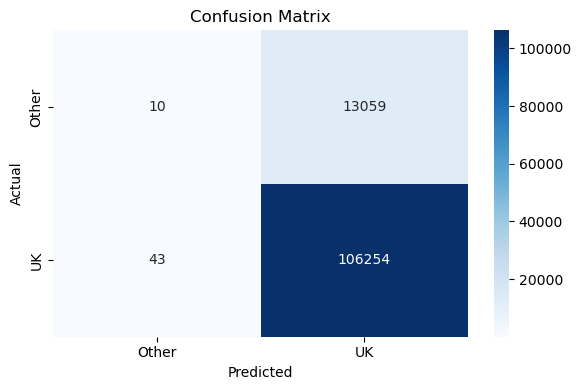

In [6]:
# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_c)
TN, FP, FN, TP = cm.ravel()

print("Confusion Matrix:")
print(cm)
print(f"\nTP = {TP}, TN = {TN}, FP = {FP}, FN = {FN}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Other', 'UK'], yticklabels=['Other', 'UK'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [7]:
# Compute All Classification Metrics
accuracy    = (TP + TN) / (TP + TN + FP + FN)
error_rate  = (FP + FN) / (TP + TN + FP + FN)
precision   = TP / (TP + FP)
sensitivity = TP / (TP + FN)        # Recall
specificity = TN / (TN + FP)
f1          = 2 * (precision * sensitivity) / (precision + sensitivity)
geometric_mean = np.sqrt(sensitivity * specificity)
fpr_val     = FP / (FP + TN)        # False Positive Rate (Type I error)
fnr_val     = FN / (TP + FN)        # False Negative Rate (Type II error)
power       = sensitivity            # Power = 1 - β

roc_auc     = roc_auc_score(y_test_c, y_prob_c)

print("=" * 50)
print("     CLASSIFICATION EVALUATION METRICS")
print("=" * 50)
print(f"  Accuracy              : {accuracy:.4f}")
print(f"  Error Rate            : {error_rate:.4f}")
print(f"  Precision             : {precision:.4f}")
print(f"  Sensitivity (Recall)  : {sensitivity:.4f}")
print(f"  Specificity           : {specificity:.4f}")
print(f"  F1 Score              : {f1:.4f}")
print(f"  Geometric Mean        : {geometric_mean:.4f}")
print(f"  False Positive Rate α : {fpr_val:.4f}")
print(f"  False Negative Rate β : {fnr_val:.4f}")
print(f"  Power (1 - β)         : {power:.4f}")
print(f"  ROC-AUC               : {roc_auc:.4f}")
print("=" * 50)

# Verify with sklearn
print("\n--- Verification with sklearn ---")
print(f"  Accuracy  (sklearn): {accuracy_score(y_test_c, y_pred_c):.4f}")
print(f"  Precision (sklearn): {precision_score(y_test_c, y_pred_c):.4f}")
print(f"  Recall    (sklearn): {recall_score(y_test_c, y_pred_c):.4f}")
print(f"  F1 Score  (sklearn): {f1_score(y_test_c, y_pred_c):.4f}")

     CLASSIFICATION EVALUATION METRICS
  Accuracy              : 0.8902
  Error Rate            : 0.1098
  Precision             : 0.8905
  Sensitivity (Recall)  : 0.9996
  Specificity           : 0.0008
  F1 Score              : 0.9419
  Geometric Mean        : 0.0277
  False Positive Rate α : 0.9992
  False Negative Rate β : 0.0004
  Power (1 - β)         : 0.9996
  ROC-AUC               : 0.7088

--- Verification with sklearn ---
  Accuracy  (sklearn): 0.8902
  Precision (sklearn): 0.8905
  Recall    (sklearn): 0.9996
  F1 Score  (sklearn): 0.9419


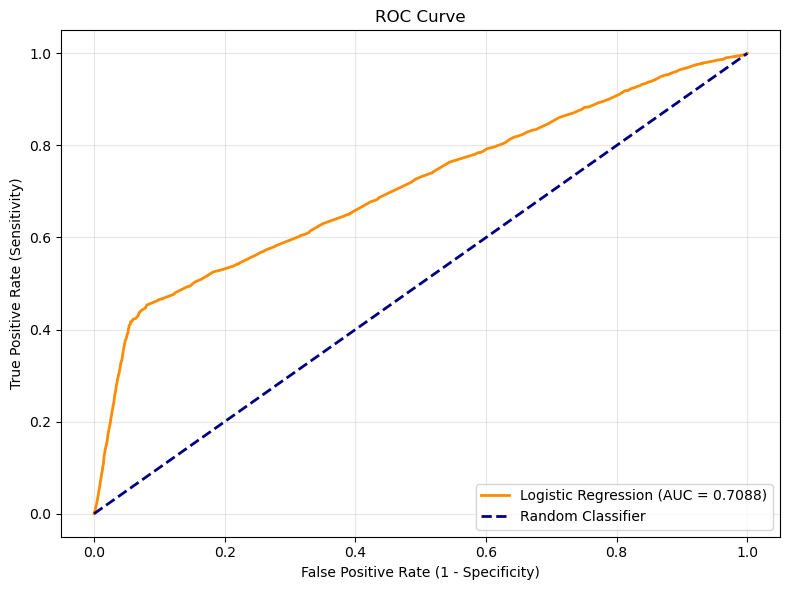

In [8]:
# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_c, y_prob_c)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 2: Regression Metrics

**Task:** Predict **UnitPrice** from Quantity and TotalPrice using Linear Regression.

We will evaluate the model using:
Pearson Correlation (r), R², MSE, RMSE, RMSRE, MAE, and MAPE.

In [9]:
# Prepare Regression Data
X_reg = df[['Quantity', 'TotalPrice']]
y_reg = df['UnitPrice']

# Train-Test Split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

# Train Linear Regression Model
reg = LinearRegression()
reg.fit(X_train_r, y_train_r)

# Predictions
y_pred_r = reg.predict(X_test_r)

print(f"Training samples: {X_train_r.shape[0]}")
print(f"Test samples    : {X_test_r.shape[0]}")

Training samples: 278518
Test samples    : 119366


In [10]:
# Compute All Regression Metrics

# 1. Pearson Correlation Coefficient (r)
r, p_value = pearsonr(y_test_r, y_pred_r)

# 2. Coefficient of Determination (R²)
r2 = r2_score(y_test_r, y_pred_r)

# 3. Mean Squared Error (MSE)
mse = mean_squared_error(y_test_r, y_pred_r)

# 4. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# 5. Root Mean Squared Relative Error (RMSRE)
rmsre = np.sqrt(np.mean(((y_test_r.values - y_pred_r) / y_test_r.values) ** 2))

# 6. Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test_r, y_pred_r)

# 7. Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test_r.values - y_pred_r) / y_test_r.values)) * 100

print("=" * 50)
print("       REGRESSION EVALUATION METRICS")
print("=" * 50)
print(f"  Pearson Correlation (r) : {r:.4f}")
print(f"  R² Score                : {r2:.4f}")
print(f"  Mean Squared Error (MSE): {mse:.4f}")
print(f"  Root MSE (RMSE)         : {rmse:.4f}")
print(f"  Root MSR Error (RMSRE)  : {rmsre:.4f}")
print(f"  Mean Absolute Error(MAE): {mae:.4f}")
print(f"  MAPE                    : {mape:.2f}%")
print("=" * 50)

       REGRESSION EVALUATION METRICS
  Pearson Correlation (r) : 0.3255
  R² Score                : 0.0602
  Mean Squared Error (MSE): 314.5739
  Root MSE (RMSE)         : 17.7362
  Root MSR Error (RMSRE)  : 11.2167
  Mean Absolute Error(MAE): 2.1765
  MAPE                    : 159.02%


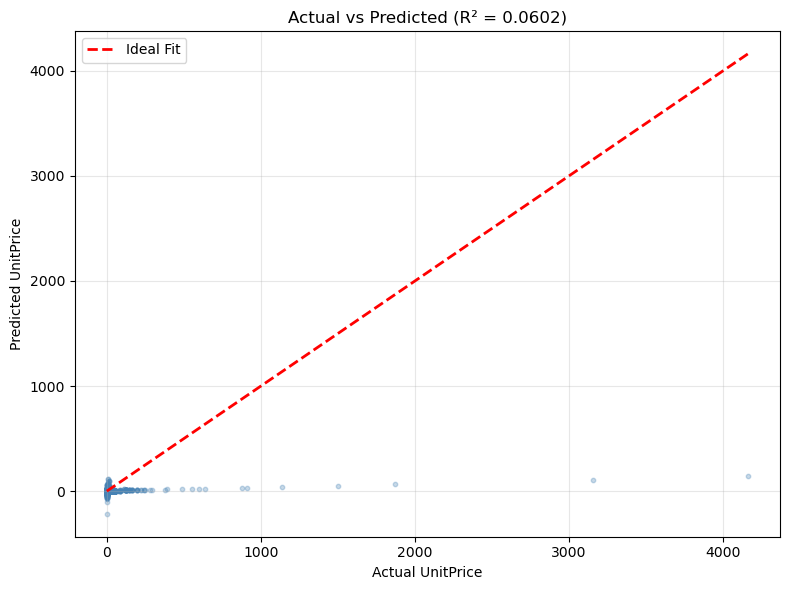

In [11]:
# Actual vs Predicted Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test_r, y_pred_r, alpha=0.3, s=10, color='steelblue')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()],
         'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual UnitPrice')
plt.ylabel('Predicted UnitPrice')
plt.title(f'Actual vs Predicted (R² = {r2:.4f})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

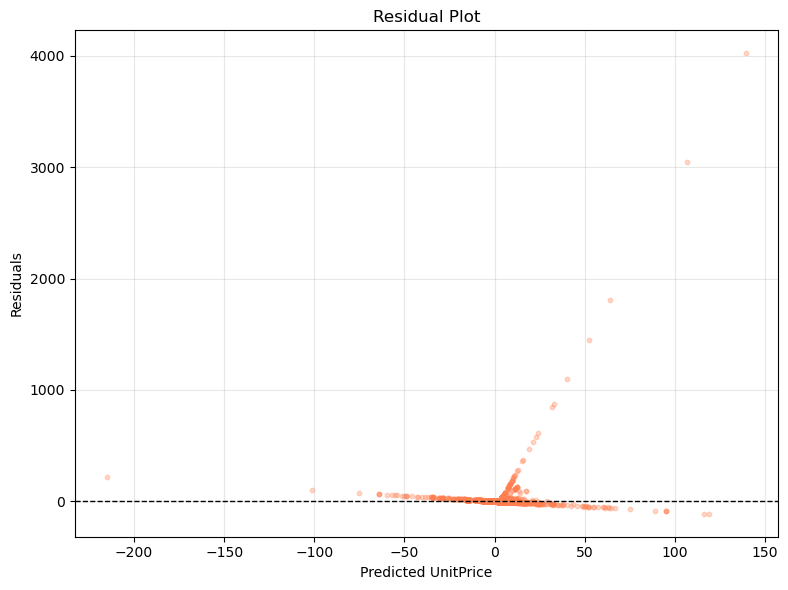

In [12]:
# Residual Plot
residuals = y_test_r.values - y_pred_r

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_r, residuals, alpha=0.3, s=10, color='coral')
plt.axhline(y=0, color='black', linestyle='--', lw=1)
plt.xlabel('Predicted UnitPrice')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Conclusion

In this experiment, we implemented and explored performance evaluation metrics for supervised learning models:

**Classification** (Logistic Regression):
- Computed Accuracy, Error Rate, Precision, Sensitivity, Specificity, F₁ Score, Geometric Mean, FPR, FNR, and ROC-AUC from the confusion matrix.
- Plotted the ROC curve to visualize classifier performance.

**Regression** (Linear Regression):
- Computed Pearson Correlation (r), R², MSE, RMSE, RMSRE, MAE, and MAPE.
- Visualized Actual vs Predicted values and Residuals.